# Re-ingest manual curation and compare the rounds (Spyglass pipeline, step 4 of 4)

This notebook closes the loop. It:

1. **Re-ingests** the `curation_data.json` produced by the SpikeInterface GUI
   ([`Pipeline_Spyglass_ManualCuration.ipynb`](Pipeline_Spyglass_ManualCuration.ipynb)) back into
   Spyglass as a new curation (`curation_id = 2`).
2. **Compares** the three curation rounds — raw (`0`), automatic (`1`), and manual (`2`).
3. **Exposes** your chosen final curation to downstream pipelines via `SpikeSortingOutput`.

> **Environment:** run this notebook with the **`spyglass`** kernel. See [`README.md`](README.md)
> for the full chain.

## Connect to the database

In [1]:
import json
from pathlib import Path
from pprint import pprint

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spikeinterface as si

# Load config for database connection info
dj_local_conf_path = "/Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json"
dj.config.load(dj_local_conf_path)

# Spyglass stores some parameters as native Python objects (dicts / lists) in the database;
# this flag lets DataJoint serialize and deserialize those blobs instead of rejecting them.
dj.config["enable_python_native_blobs"] = True

# General Spyglass imports (importing common connects to the database)
import spyglass.common as sgc
import spyglass.spikesorting.v1 as sgs
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-06-17 10:25:10,117][INFO]: DataJoint is configured from /Users/pauladkisson/Documents/CatalystNeuro/Spyglass/spyglass/dj_local_conf.json
[2026-06-17 10:25:10,444][INFO]: DataJoint 0.14.9 connected to root@localhost:3306
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Parameters set manually

These must match the earlier notebooks.

In [2]:
### Parameters set manually ###

# Session: the NWB copy that lives in the database (note the trailing underscore)
nwb_file_name = get_nwb_copy_filename("H3022-210806.nwb")  # -> "H3022-210806_.nwb"

# Which shank (sort group) and which epoch (interval) were sorted
sort_group_id = 0
interval_list_name = "01"  # first wake epoch for this session

# Pipeline parameters (must match the values used in Pipeline_Spyglass_SpikeSorting.ipynb)
preproc_param_name = "default"
sorter = "mountainsort5"
sorter_param_name = "default"

# Shared handoff folder for the manual-curation step (notebooks 2 -> 3 -> 4). Kept outside the git
# repo so the exported recording/sorting are not picked up as untracked files. Must match the
# export_root set in Pipeline_Spyglass_AutomaticCuration.ipynb.
export_root = Path("/Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/curation_exports")

## Recover the sorting

In [3]:
# Re-derive the sorting produced by Pipeline_Spyglass_SpikeSorting.ipynb from the parameters
# above. Every stage is keyed off the recording, so we first recover its recording_id, then the
# sorting_id, then point at the raw curation (curation_id = 0) that notebook registered.
recording_id = (
    sgs.SpikeSortingRecordingSelection
    & {
        "nwb_file_name": nwb_file_name,
        "sort_group_id": sort_group_id,
        "interval_list_name": interval_list_name,
        "preproc_param_name": preproc_param_name,
    }
).fetch1("recording_id")

sorting_id = (
    sgs.SpikeSortingSelection
    & {
        "recording_id": recording_id,
        "sorter": sorter,
        "sorter_param_name": sorter_param_name,
    }
).fetch1("sorting_id")

curation_key = {"sorting_id": sorting_id, "curation_id": 0}
assert sgs.CurationV1 & curation_key, (
    "No raw curation (curation_id = 0) found for this sorting. "
    "Run Pipeline_Spyglass_SpikeSorting.ipynb first."
)
sgs.CurationV1 & {"sorting_id": sorting_id}

sorting_id,curation_id,parent_curation_id,analysis_file_name name of the file,object_id,merges_applied,description
62224b1f-3d21-498f-bdc3-02c7e398ce77,0,-1,H3022-210806_NYOV44E825.nwb,626eed1e-2797-4cee-8720-aa2ea255a509,0,"raw sort, no curation"
62224b1f-3d21-498f-bdc3-02c7e398ce77,1,0,H3022-210806_XN2FAIZD0N.nwb,692a70c8-24de-48ae-9cb0-f322afe74b71,0,after metric curation
62224b1f-3d21-498f-bdc3-02c7e398ce77,2,0,H3022-210806_JUOVTP1TQH.nwb,e805fead-0c19-442e-aa78-1a3a1c05c838,0,after manual curation (SpikeInterface GUI)
62224b1f-3d21-498f-bdc3-02c7e398ce77,3,-1,H3022-210806_N677TE2AU1.nwb,a25469f0-688f-402c-8228-7e8ec78f1d78,0,"raw sort, no curation"


## 1. Re-ingest the manual curation

The GUI writes curation in the SpikeInterface **v2 curation format**: `manual_labels` (per-unit
labels under a `"quality"` category of `good` / `noise` / `MUA`), `merges` (groups of unit ids),
and `removed` (units deleted as noise). Spyglass's `insert_curation` instead wants a
`labels = {unit_id: [label, ...]}` dict and `merge_groups = [[unit_id, ...], ...]`, where the valid
labels are `reject`, `noise`, `artifact`, `mua`, `accept`. The cell below translates between the
two and inserts the result as `curation_id = 2`, branching off the raw sort.

In [4]:
export_dir = export_root / str(sorting_id)
curation_json_path = export_dir / "sorting_analyzer" / "spikeinterface_gui" / "curation_data.json"
assert curation_json_path.exists(), (
    f"No curation file at {curation_json_path}. "
    "Run Pipeline_Spyglass_ManualCuration.ipynb (step 3) and save in the GUI first."
)

with open(curation_json_path) as file:
    gui_curation = json.load(file)

# Map the GUI's quality labels onto Spyglass's valid labels.
LABEL_MAP = {"good": "accept", "noise": "noise", "MUA": "mua", "mua": "mua"}

labels = {}
for entry in gui_curation.get("manual_labels", []):
    unit_id = entry["unit_id"]
    flat = [
        LABEL_MAP.get(label, label)
        for label_list in entry["labels"].values()
        for label in label_list
    ]
    if flat:
        labels[unit_id] = flat

# Units removed in the GUI are treated as rejected.
for unit_id in gui_curation.get("removed", []):
    labels.setdefault(unit_id, []).append("reject")

merge_groups = [group["unit_ids"] for group in gui_curation.get("merges", [])]

print(f"manual labels: {labels}")
print(f"manual merge groups: {merge_groups}")

manual labels: {1: ['reject']}
manual merge groups: [[14, 15]]


In [10]:
# `insert_curation` always appends a new curation_id (it only de-dupes the raw parent=-1 case), so
# re-running this cell would keep stacking identical "manual" curations. Guard against that.
manual_description = "after manual curation (SpikeInterface GUI)"
existing_manual = sgs.CurationV1 & {"sorting_id": sorting_id, "description": manual_description}
if existing_manual:
    print(
        f"Manual curation already inserted (curation_id {list(existing_manual.fetch('curation_id'))}); "
        "skipping. Delete it first if you want to re-ingest updated GUI results."
    )
else:
    sgs.CurationV1.insert_curation(
        sorting_id=sorting_id,
        parent_curation_id=0,
        labels=labels or None,
        merge_groups=merge_groups or None,
        description=manual_description,
    )
sgs.CurationV1 & {"sorting_id": sorting_id}

[10:27:06][INFO] Spyglass: Writing new NWB file H3022-210806_XFW1ZLCFJB.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequiredBuildWarning: NWBFile 'root' is missing required value for attribute 'source_script_file_name'.
  warnings.warn(msg, MissingRequiredBuildWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:738: MissingRequired

sorting_id,curation_id,parent_curation_id,analysis_file_name name of the file,object_id,merges_applied,description
62224b1f-3d21-498f-bdc3-02c7e398ce77,0,-1,H3022-210806_NYOV44E825.nwb,626eed1e-2797-4cee-8720-aa2ea255a509,0,"raw sort, no curation"
62224b1f-3d21-498f-bdc3-02c7e398ce77,1,0,H3022-210806_XN2FAIZD0N.nwb,692a70c8-24de-48ae-9cb0-f322afe74b71,0,after metric curation
62224b1f-3d21-498f-bdc3-02c7e398ce77,2,0,H3022-210806_XFW1ZLCFJB.nwb,8cb93462-2f67-4cc0-b1a0-83bbb72c737e,0,after manual curation (SpikeInterface GUI)


## 2. Compare the curation rounds

For each curation that exists, we summarize the unit count, how many units were labeled (and with
what), how many merge groups were defined, and the unit count after applying those merges.

In [11]:
round_names = {0: "raw", 1: "automatic", 2: "manual"}
available_ids = sorted((sgs.CurationV1 & {"sorting_id": sorting_id}).fetch("curation_id"))


def merge_groups_from_units(units):
    """Reconstruct merge groups (components of >=2 units) from the per-unit `merge_groups` column.

    Spyglass stores, for each unit, the list of other unit ids it should merge with (a unit with no
    merges is stored as ``['']``, so empty strings are dropped). We treat that as an adjacency list
    and return its connected components of size > 1. We read the units table directly because
    `CurationV1.get_merged_sorting` routes through `read_nwb_sorting`, which trips over the ragged
    `curation_label` column.
    """
    if "merge_groups" not in units.columns:
        return []
    adjacency = {
        str(unit_id): {str(partner) for partner in partners if str(partner)}
        for unit_id, partners in units["merge_groups"].items()
    }
    seen, groups = set(), []
    for unit_id in adjacency:
        if unit_id in seen:
            continue
        stack, component = [unit_id], []
        while stack:
            current = stack.pop()
            if current in seen:
                continue
            seen.add(current)
            component.append(current)
            stack.extend(adjacency.get(current, ()))
        if len(component) > 1:
            groups.append(component)
    return groups


summary_rows = []
spike_times_by_round = {}
labels_by_round = {}
for curation_id in available_ids:
    key = {"sorting_id": sorting_id, "curation_id": curation_id}
    units = sgs.CurationV1.get_sorting(key, as_dataframe=True)

    # Per-unit labels (the raw sort has no curation_label column).
    if "curation_label" in units.columns:
        unit_labels = {idx: list(row) for idx, row in units["curation_label"].items()}
    else:
        unit_labels = {idx: [] for idx in units.index}
    labels_by_round[curation_id] = unit_labels

    label_tally = {}
    for unit_label_list in unit_labels.values():
        for label in unit_label_list:
            label_tally[label] = label_tally.get(label, 0) + 1

    merge_groups = merge_groups_from_units(units)
    n_merged_away = sum(len(group) - 1 for group in merge_groups)

    summary_rows.append(
        {
            "curation_id": curation_id,
            "round": round_names.get(curation_id, str(curation_id)),
            "n_units": len(units),
            "n_merge_groups": len(merge_groups),
            "n_units_after_merge": len(units) - n_merged_away,
            "n_labeled": sum(1 for unit_labels_list in unit_labels.values() if len(unit_labels_list) > 0),
            "labels": label_tally,
        }
    )

    sorting_obj = sgs.CurationV1.get_sorting(key)
    spike_times_by_round[curation_id] = {
        unit_id: sorting_obj.get_unit_spike_train(unit_id, return_times=True)
        for unit_id in sorting_obj.get_unit_ids()
    }

pd.DataFrame(summary_rows).set_index("curation_id")

/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
[2026-06-17 10:27:26,573][WARNING]: Skipped checksum for file with hash: b8116206-ce71-028e-7a4f-a0cf70b4edd3, and path: /Users/pauladkisson/Documents/CatalystNeuro/DudchenkoConv/Spyglass/analysis/H3022-210806/H3022-210806_GL3SRK02VF.nwb
/opt/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/camera_device 0/model
  warnings.

,round,n_units,n_merge_groups,n_units_after_merge,n_labeled,labels
curation_id,,,,,,
0,raw,19,0,19,0,{}
1,automatic,19,0,19,4,"{'noise': 2, 'mua': 3}"
2,manual,19,1,18,1,{'reject': 1}


### Spike rasters by curation round

The same window for every round. Units that the round labeled `noise`/`reject` are drawn in grey;
all other units are colored. This makes the effect of each curation visible at a glance.

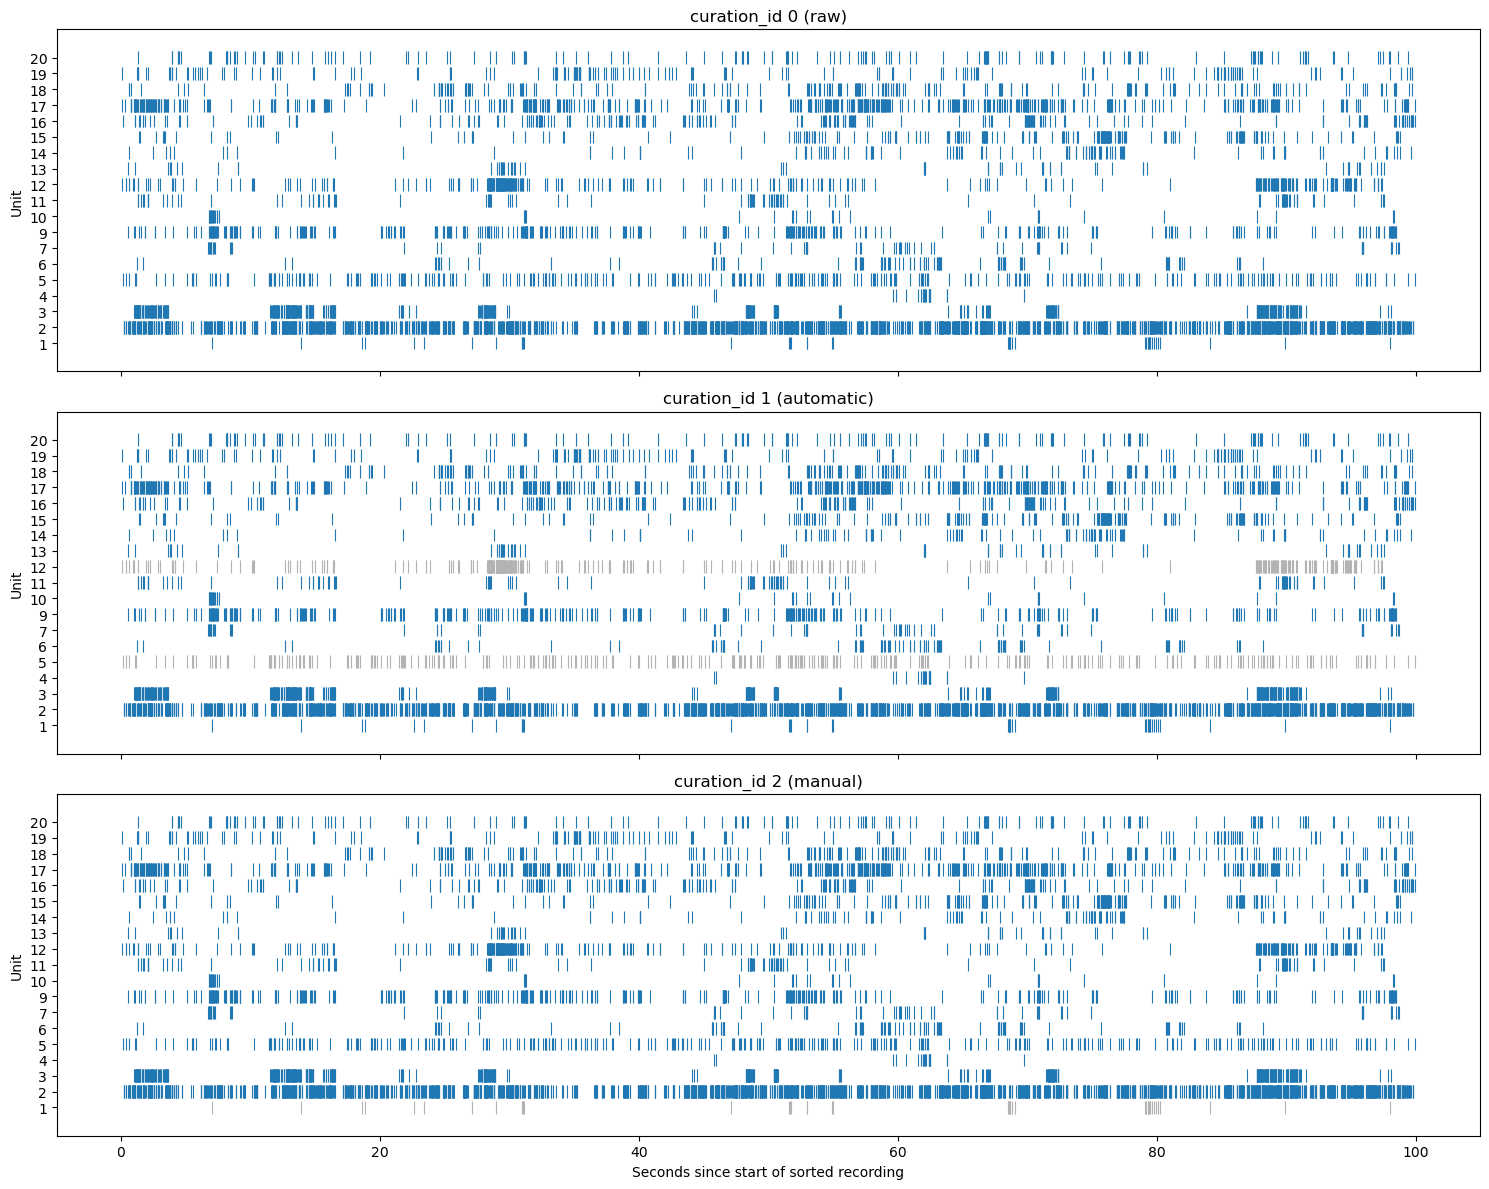

In [12]:
raster_duration = 100.0  # seconds from the start of the sorted recording to display


def in_window(times, stop):
    times = np.asarray(times)
    return times[(times >= 0.0) & (times <= stop)]


fig, axes = plt.subplots(len(available_ids), 1, figsize=(15, 4 * len(available_ids)), sharex=True)
axes = np.atleast_1d(axes)
for ax, curation_id in zip(axes, available_ids):
    spike_times = spike_times_by_round[curation_id]
    unit_labels = labels_by_round[curation_id]
    unit_ids = list(spike_times.keys())
    windowed = [in_window(spike_times[unit_id], raster_duration) for unit_id in unit_ids]
    colors = [
        "0.7"
        if any(label in ("noise", "reject") for label in unit_labels.get(unit_id, []))
        else "tab:blue"
        for unit_id in unit_ids
    ]
    ax.eventplot(windowed, linelengths=0.8, linewidths=0.8, colors=colors)
    ax.set_yticks(range(len(unit_ids)))
    ax.set_yticklabels(unit_ids)
    ax.set_ylabel("Unit")
    ax.set_title(f"curation_id {curation_id} ({round_names.get(curation_id, curation_id)})")
axes[-1].set_xlabel("Seconds since start of sorted recording")
plt.tight_layout()

## 3. Expose the chosen curation downstream

Pick which curation should be the one downstream pipelines use, and insert it into the
`SpikeSortingOutput` merge table. Each `(sorting_id, curation_id)` becomes its own `merge_id`, so
this does not disturb the raw `curation_id = 0` entry that step 1 already inserted — multiple
curations of the same sorting can coexist there.

In [13]:
# Choose the final curation to expose: 0 (raw), 1 (automatic), or 2 (manual).
final_curation_id = 2

final_curation_key = {"sorting_id": sorting_id, "curation_id": final_curation_id}
SpikeSortingOutput.insert(
    (sgs.CurationV1 & final_curation_key).fetch("KEY", as_dict=True),
    part_name="CurationV1",
)
SpikeSortingOutput.merge_view()

*merge_id      *source        *sorting_id    *curation_id   *nwb_file_name
+------------+ +------------+ +------------+ +------------+ +------------+
045b9965-9cea- ImportedSpikeS None           0              H4819-220929_.
048a2f6c-b630- ImportedSpikeS None           0              H4827-221210_.
0b425267-f081- ImportedSpikeS None           0              H4822-221023_.
0c353fbf-e6be- CurationV1     62224b1f-3d21- 2              None          
0f0b203d-5d95- ImportedSpikeS None           0              H3026-211004_2
13ae1d88-f0d2- ImportedSpikeS None           0              H3029-230510_.
16b94a6e-1155- ImportedSpikeS None           0              H4825-221124_.
18293671-bb23- ImportedSpikeS None           0              H3015-210416_1
1aa93663-216a- ImportedSpikeS None           0              H4826-221203_.
26a370c8-12ff- ImportedSpikeS None           0              H3023-210812_.
26c458e7-add2- ImportedSpikeS None           0              H3019-210618_1
30e9d5bf-aa2c- ImportedSp